<a href="https://colab.research.google.com/github/famub/Zero-to-Mastery-Learn-PyTorch-for-Deep-Learning-Exercises/blob/main/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Mon Jul 20 01:31:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

2.11.0+cu128


## 1. What are 3 areas in industry where computer vision is currently being used?

In [3]:
# 1. Self-driving cars
# 2. Ulocking phones
# 3. Security

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
# Overfitting occurs when the model have a low training error & a high testing error

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [5]:
# 1. Data Augmentation - Creat "new data" from the existing data, to improve the model generalization.
# 2. Early stopping - Asses the model performane during training using a validation set. At a certain performance threshold, stop the training.
# 3. Cross-validation (K-fold) - by training k models and seeing their performance you can estimate the used algorithm generalization performance.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [6]:
import torch
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train = MNIST(root="data", train=True, download=True, transform=ToTensor())
test = MNIST(root="data", train=False, download=True, transform=ToTensor())

classes = train.classes
classes

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.88MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [30]:
train, test

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [7]:
img, label = train[0]
img, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [8]:
img.shape

torch.Size([1, 28, 28])

## 6. Visualize at least 5 different samples of the MNIST training dataset.

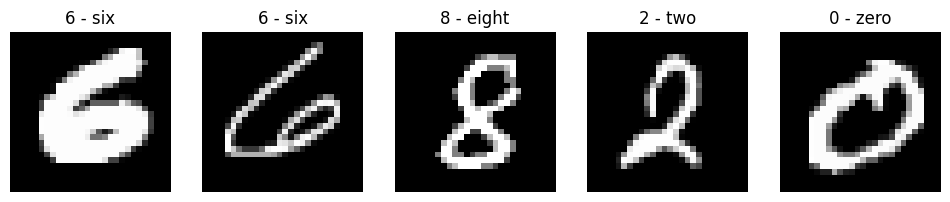

In [9]:
import matplotlib.pyplot as plt

torch.manual_seed(42)

fig = plt.figure(figsize=(12, 9))

for i in range(0, 5):
  rand_i = torch.randint(0, len(train), size=[1]).item()
  img, label = train[rand_i]
  fig.add_subplot(1, 5, i + 1)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(classes[label])
  plt.axis(False);

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [31]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset=train, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test, batch_size=32, shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [93]:
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self, input_size: int, output_size: int, hidden_units: int):
    super().__init__()
    self.layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_size, out_channels=hidden_units, kernel_size=3, stride=1),   # Convolutional layer, 2 d since our data (images) has 2 dim.s (hieght and width)
        nn.ReLU(),   # Activation layer
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=1)   # Pooling layer
    )
    self.layer_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
        nn.MaxPool2d(kernel_size=2, stride=1)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 324, out_features=output_size)
    )
  def forward(self, x: torch.Tensor):
    x = self.layer_1(x)
    #print(f"After layer 1:{x.shape}")
    x = self.layer_2(x)
    #print(f"After layer 2:{x.shape}")
    x = self.classifier(x)
    #print(f"After classifier:{x.shape}")
    return x

model_0 = TinyVGG(input_size=1, output_size=len(classes), hidden_units=10).to(device)
model_0

TinyVGG(
  (layer_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3240, out_features=10, bias=True)
  )
)

In [94]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [95]:
# try dummy forward

torch.manual_seed(42)
torch.cuda.manual_seed(42)

dummy = torch.randn(size=(1, 28, 28)).unsqueeze(dim=0).to(device)
model_0(dummy)

tensor([[ 0.0078,  0.0058, -0.0236,  0.0621,  0.0795, -0.0293,  0.0431,  0.0851,
          0.0045, -0.0429]], device='cuda:0', grad_fn=<AddmmBackward0>)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [96]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("exists")
else:
  req = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(req.content)

exists


In [97]:
from helper_functions import accuracy_fn

model_0.to(device) # Move model to target device before initializing optimizer
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01) # Reduced learning rate to 0.01

In [98]:
from tqdm.auto import tqdm

epochs = 5
for epoch in tqdm(range(epochs)):

  print(f"Epoch: {epoch}")
  train_loss, train_acc = 0, 0

  model_0.train()
  for batch, (X, y) in enumerate(train_loader):
    X, y = X.to(device), y.to(device)

    y_pred = model_0(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

    optim.zero_grad()

    loss.backward()

    optim.step()

  train_loss /= len(train_loader)
  train_acc /= len(train_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

  test_loss, test_acc = 0, 0

  model_0.eval()
  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_loader):
      X, y = X.to(device), y.to(device)

      y_pred = model_0(X)

      test_loss += loss_fn(y_pred, y)
      test_acc += accuracy_fn(y, y_pred.argmax(dim=1))

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
Train loss: 0.51066 | Train accuracy: 83.87%
Test loss: 0.20394 | Test accuracy: 94.48%
Epoch: 1
Train loss: 0.16487 | Train accuracy: 95.12%
Test loss: 0.11442 | Test accuracy: 96.52%
Epoch: 2
Train loss: 0.10912 | Train accuracy: 96.71%
Test loss: 0.08542 | Test accuracy: 97.30%
Epoch: 3
Train loss: 0.08317 | Train accuracy: 97.46%
Test loss: 0.07019 | Test accuracy: 97.81%
Epoch: 4
Train loss: 0.06978 | Train accuracy: 97.84%
Test loss: 0.05878 | Test accuracy: 97.97%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [123]:
def pred(model: torch.nn.Module, data, device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = sample.to(device)
      pred_logits = model(sample.unsqueeze(dim=0))
      pred_prob = torch.softmax(pred_logits, dim=1)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [124]:
import random

random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test), k = 5):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape, test_labels[0], classes[test_labels[0]]

(torch.Size([1, 28, 28]), 2, '2 - two')

In [128]:
pred_probs = pred(model_0, test_samples)

pred_probs[0]

tensor([[3.1283e-08, 4.2015e-08, 1.0000e+00, 1.5681e-06, 1.8655e-15, 7.0006e-11,
         2.3603e-10, 1.1612e-08, 1.5086e-06, 1.2537e-07]])

In [130]:
pred_classes = pred_probs.squeeze(1).argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6])

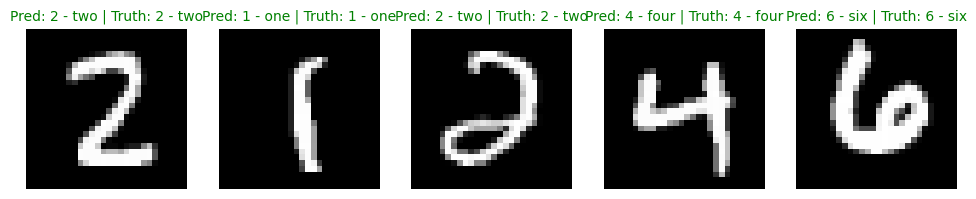

In [132]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

fig = plt.figure(figsize=(12, 9))

for i, sample in enumerate(test_samples):
  fig.add_subplot(1, 5, i + 1)
  plt.imshow(sample.squeeze(), cmap="gray")
  pred_label = classes[pred_classes[i]]
  truth_label = classes[test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong

  plt.axis(False);

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [133]:
y_preds = []
model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_loader):
    X, y = X.to(device), y.to(device)
    y_logits = model_0(X)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

  0%|          | 0/313 [00:00<?, ?it/s]

In [135]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.4 MB/s eta 0:00:00


In [136]:
import torchmetrics, mlxtend

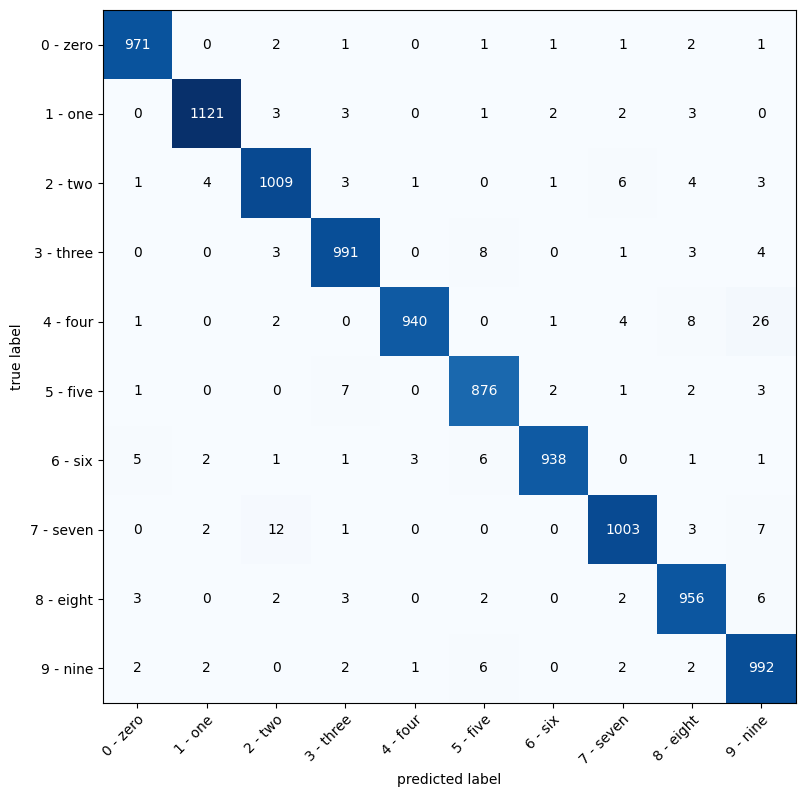

In [137]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(classes), task='multiclass')
confmat_tensot = confmat(preds=y_pred_tensor, target=test.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensot.numpy(),
    figsize=(12, 9),
    class_names=classes,
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?